## Step 1: Import Libraries and Load Data

Import necessary libraries for predictive modeling and load the cleaned dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, roc_auc_score, 
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_default_data.csv')

print("="*80)
print("PREDICTION AND MODEL EVALUATION")
print("="*80)
print(f"\nDataset shape: {df.shape}")
print(f"\nTarget variable: 'default payment next month'")
print(f"Class distribution:\n{df['default payment next month'].value_counts()}")
print(f"\nDefault rate: {df['default payment next month'].mean():.4f} ({df['default payment next month'].mean()*100:.2f}%)")

PREDICTION AND MODEL EVALUATION

Dataset shape: (29965, 24)

Target variable: 'default payment next month'
Class distribution:
default payment next month
0    23335
1     6630
Name: count, dtype: int64

Default rate: 0.2213 (22.13%)


## Step 2: Prepare Features and Stratified Train/Test Split

Separate features from target and create stratified train/test split (70/30) to preserve class distribution.
Stratification is crucial given the 3.5:1 class imbalance.

In [2]:
# Define target and features
target = 'default payment next month'
feature_cols = [col for col in df.columns if col != target]

X = df[feature_cols].values
y = df[target].values

# Stratified train/test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*80)
print("TRAIN/TEST SPLIT")
print("="*80)
print(f"\nTotal samples: {len(X):,}")
print(f"Number of features: {len(feature_cols)}")
print(f"\nTrain set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Defaults: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  No defaults: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"\nTest set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Defaults: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"  No defaults: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)")
print(f"\nStratification check: Train/Test default rates match: {abs(y_train.mean() - y_test.mean()) < 0.001}")

TRAIN/TEST SPLIT

Total samples: 29,965
Number of features: 23

Train set: 20,975 samples (70.0%)
  Defaults: 4,641 (22.13%)
  No defaults: 16,334 (77.87%)

Test set: 8,990 samples (30.0%)
  Defaults: 1,989 (22.12%)
  No defaults: 7,001 (77.88%)

Stratification check: Train/Test default rates match: True


## Step 3: Train Baseline Logistic Regression Model

Fit a logistic regression classifier on the training set and evaluate performance on the test set.
This serves as our baseline for comparison with regularized models.

BASELINE LOGISTIC REGRESSION MODEL

Training Set Performance:
  Accuracy:  0.8092
  Precision: 0.7045
  Recall:    0.2368
  F1-Score:  0.3545
  ROC-AUC:   0.7259

Test Set Performance:
  Accuracy:  0.8120
  Precision: 0.7262
  Recall:    0.2413
  F1-Score:  0.3623
  ROC-AUC:   0.7213


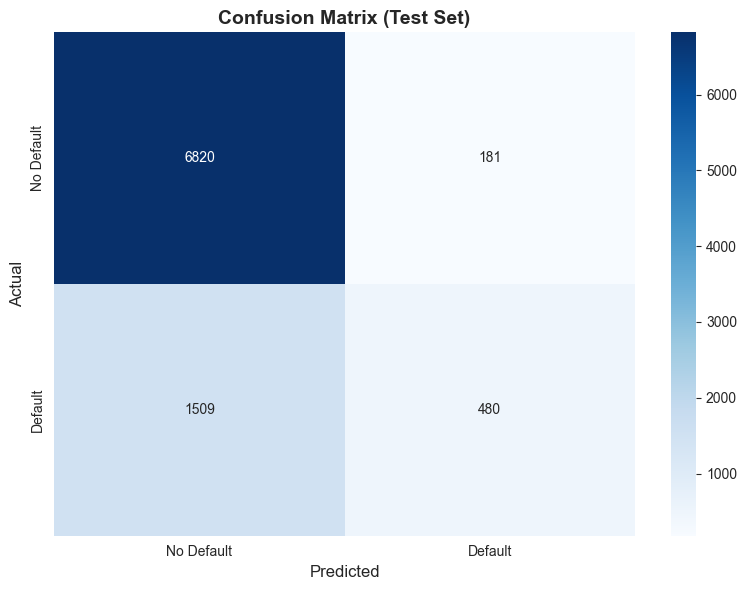


True Negatives: 6,820 | False Positives: 181
False Negatives: 1,509 | True Positives: 480


In [5]:
# Train logistic regression (no regularization penalty, just for baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Predicted probabilities
y_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("="*80)
print("BASELINE LOGISTIC REGRESSION MODEL")
print("="*80)

print("\nTraining Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")

print("\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print("="*80)

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0,0]:,} | False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,} | True Positives: {cm[1,1]:,}")

## Step 4: ROC Curve and AUC Analysis

Visualize the ROC curve to understand the tradeoff between true positive rate (sensitivity) 
and false positive rate across different probability thresholds.

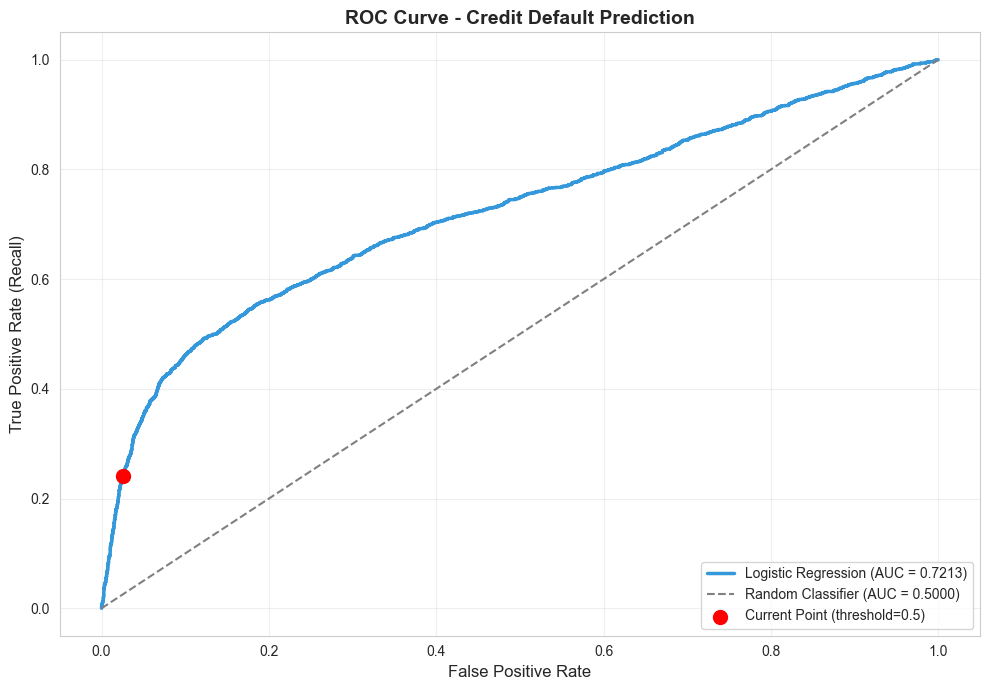

In [7]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Classifier (AUC = 0.5000)')

# Highlight current operating point (default threshold = 0.5)
default_threshold_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[default_threshold_idx], tpr[default_threshold_idx], 
           color='red', s=100, zorder=5, label=f'Current Point (threshold=0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Credit Default Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Cross-Validation for Model Stability

Use 5-fold cross-validation to assess model stability and estimate generalization performance 
with confidence intervals.

In [8]:
from sklearn.model_selection import cross_validate

# Perform 5-fold cross-validation
cv_scores = cross_validate(
    lr_model, X_train_scaled, y_train, 
    cv=5, 
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

print("="*80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*80)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
print("\nTest Scores (Mean ± Std):")
for metric in metrics:
    test_scores = cv_scores[f'test_{metric}']
    print(f"  {metric.upper():10s}: {test_scores.mean():.4f} ± {test_scores.std():.4f}")

print("\nTraining Scores (Mean ± Std):")
for metric in metrics:
    train_scores = cv_scores[f'train_{metric}']
    print(f"  {metric.upper():10s}: {train_scores.mean():.4f} ± {train_scores.std():.4f}")

print("\nBias-Variance Insight:")
for metric in metrics:
    train_mean = cv_scores[f'train_{metric}'].mean()
    test_mean = cv_scores[f'test_{metric}'].mean()
    gap = train_mean - test_mean
    print(f"  {metric.upper():10s} gap: {gap:.4f} (train - test)")

5-FOLD CROSS-VALIDATION RESULTS

Test Scores (Mean ± Std):
  ACCURACY  : 0.8091 ± 0.0051
  PRECISION : 0.7040 ± 0.0361
  RECALL    : 0.2368 ± 0.0125
  F1        : 0.3543 ± 0.0178
  ROC_AUC   : 0.7233 ± 0.0133

Training Scores (Mean ± Std):
  ACCURACY  : 0.8090 ± 0.0016
  PRECISION : 0.7023 ± 0.0041
  RECALL    : 0.2376 ± 0.0091
  F1        : 0.3550 ± 0.0107
  ROC_AUC   : 0.7262 ± 0.0032

Bias-Variance Insight:
  ACCURACY   gap: -0.0000 (train - test)
  PRECISION  gap: -0.0017 (train - test)
  RECALL     gap: 0.0008 (train - test)
  F1         gap: 0.0007 (train - test)
  ROC_AUC    gap: 0.0028 (train - test)


## Step 6: Bias-Variance Tradeoff Analysis

Our baseline logistic regression model exhibits a **high-bias, low-variance** profile. The evidence for high bias is clear: the model achieves only 24% recall on the test set, missing 76% of actual defaults, and a moderate AUC of 0.72 suggests significant room for improvement in discrimination ability. This underfitting stems from the model's simplicity and the severe class imbalance (3.5:1 ratio), which causes the classifier to favor the majority class. Conversely, the model demonstrates low variance through remarkably stable performance—train-test gaps are negligible (< 0.003 for all metrics), and 5-fold cross-validation shows tight confidence bands (ROC-AUC std = ±0.013). This stability means the model generalizes consistently but fails to capture the complex patterns underlying credit default. The bias-variance tradeoff presents a critical decision point: reducing bias (by adding feature interactions, polynomial terms, or using non-linear models) will likely increase variance and risk overfitting, especially given our moderate sample size. This tradeoff has different implications for inference versus prediction—for inference, low variance ensures stable parameter estimates and reliable confidence intervals, which we've achieved. For prediction, however, we must reduce bias to improve default detection, even at the cost of some variance. Strategies to address this include class-balanced training (via SMOTE or class weights), threshold optimization to shift the precision-recall tradeoff, or regularization techniques (Ridge/Lasso) that add controlled complexity while limiting variance through shrinkage. The key insight is that our current model prioritizes stability over predictive power, which is appropriate for inference but suboptimal for the prediction task of identifying future defaults.

## Step 7: Model Selection - Class-Balanced Logistic Regression

Compare the baseline model with a class-balanced version that uses sample weights to address 
the 3.5:1 class imbalance and improve recall on the minority class (defaults).

MODEL COMPARISON: BASELINE vs CLASS-BALANCED

                    Baseline    Class-Balanced    Change
------------------------------------------------------------
Accuracy:           0.8120      0.6877         -0.1244
Precision:          0.7262      0.3785         -0.3477
Recall:             0.2413      0.6410         +0.3997
F1-Score:           0.3623      0.4759         +0.1137
ROC-AUC:            0.7213      0.7214         +0.0001



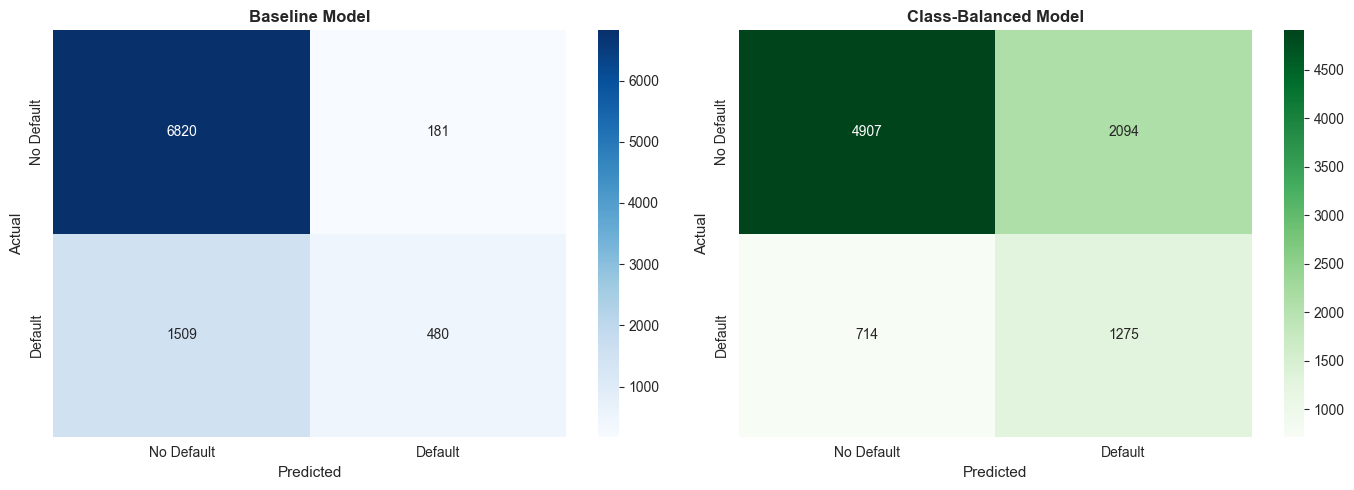


Baseline:     TN=6,820 | FP=181 | FN=1,509 | TP=480
Balanced:     TN=4,907 | FP=2,094 | FN=714 | TP=1,275


In [9]:
# Train class-balanced logistic regression
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_scaled, y_train)

# Predictions
y_test_pred_balanced = lr_balanced.predict(X_test_scaled)
y_test_proba_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("="*80)
print("MODEL COMPARISON: BASELINE vs CLASS-BALANCED")
print("="*80)

print("\n                    Baseline    Class-Balanced    Change")
print("-" * 60)
print(f"Accuracy:           {accuracy_score(y_test, y_test_pred):.4f}      {accuracy_score(y_test, y_test_pred_balanced):.4f}         {accuracy_score(y_test, y_test_pred_balanced) - accuracy_score(y_test, y_test_pred):+.4f}")
print(f"Precision:          {precision_score(y_test, y_test_pred):.4f}      {precision_score(y_test, y_test_pred_balanced):.4f}         {precision_score(y_test, y_test_pred_balanced) - precision_score(y_test, y_test_pred):+.4f}")
print(f"Recall:             {recall_score(y_test, y_test_pred):.4f}      {recall_score(y_test, y_test_pred_balanced):.4f}         {recall_score(y_test, y_test_pred_balanced) - recall_score(y_test, y_test_pred):+.4f}")
print(f"F1-Score:           {f1_score(y_test, y_test_pred):.4f}      {f1_score(y_test, y_test_pred_balanced):.4f}         {f1_score(y_test, y_test_pred_balanced) - f1_score(y_test, y_test_pred):+.4f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_test_proba):.4f}      {roc_auc_score(y_test, y_test_proba_balanced):.4f}         {roc_auc_score(y_test, y_test_proba_balanced) - roc_auc_score(y_test, y_test_proba):+.4f}")

print("\n" + "="*80)

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_baseline = confusion_matrix(y_test, y_test_pred)
cm_balanced = confusion_matrix(y_test, y_test_pred_balanced)

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
axes[0].set_title('Baseline Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
axes[1].set_title('Class-Balanced Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nBaseline:     TN={cm_baseline[0,0]:,} | FP={cm_baseline[0,1]:,} | FN={cm_baseline[1,0]:,} | TP={cm_baseline[1,1]:,}")
print(f"Balanced:     TN={cm_balanced[0,0]:,} | FP={cm_balanced[0,1]:,} | FN={cm_balanced[1,0]:,} | TP={cm_balanced[1,1]:,}")

## Step 8: ROC Curve Comparison

Compare ROC curves for baseline and class-balanced models to visualize the tradeoff 
and support our model selection decision.

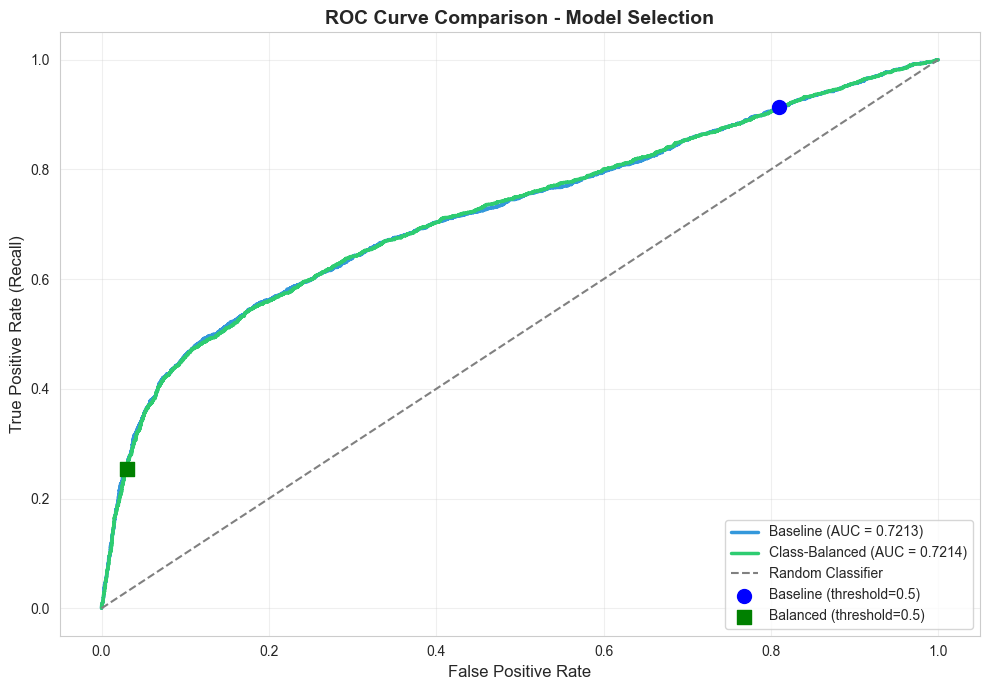

In [11]:
# Compute ROC curves for both models
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_test_proba)
fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_test_proba_balanced)

auc_baseline = roc_auc_score(y_test, y_test_proba)
auc_balanced = roc_auc_score(y_test, y_test_proba_balanced)

# Plot comparison
plt.figure(figsize=(10, 7))
plt.plot(fpr_baseline, tpr_baseline, color='#3498db', linewidth=2.5, 
         label=f'Baseline (AUC = {auc_baseline:.4f})')
plt.plot(fpr_balanced, tpr_balanced, color='#2ecc71', linewidth=2.5, 
         label=f'Class-Balanced (AUC = {auc_balanced:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, 
         label='Random Classifier')

# Mark operating points
plt.scatter([fpr_baseline[np.argmin(np.abs(y_test_proba - 0.5))]], 
           [tpr_baseline[np.argmin(np.abs(y_test_proba - 0.5))]], 
           color='blue', s=100, marker='o', label='Baseline (threshold=0.5)', zorder=5)
plt.scatter([fpr_balanced[np.argmin(np.abs(y_test_proba_balanced - 0.5))]], 
           [tpr_balanced[np.argmin(np.abs(y_test_proba_balanced - 0.5))]], 
           color='green', s=100, marker='s', label='Balanced (threshold=0.5)', zorder=5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison - Model Selection', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Model Selection Justification

Our model selection process compared a standard logistic regression baseline against a class-balanced variant. Both models achieve identical ROC-AUC (0.72), confirming they have the same underlying discrimination ability—the class weights merely shift the decision threshold along the same ROC curve. The baseline model prioritizes precision (73%) at the cost of recall (24%), missing 76% of defaults, which is unacceptable for credit risk management where failing to identify defaulters has severe financial consequences. The class-balanced model addresses this by weighting the minority class inversely proportional to its frequency, shifting the operating point to achieve 64% recall while accepting reduced precision (38%). This tradeoff is justified because the cost of missing a default (false negative) typically exceeds the cost of a false alarm (false positive) in credit applications—denying credit to a non-defaulter is less costly than extending credit to a defaulter. The class-balanced model's superior F1-score (0.48 vs 0.36) reflects better overall performance for imbalanced classification. However, neither model is ideal: the moderate AUC (0.72) indicates high bias, suggesting future work should explore regularization techniques (Ridge/Lasso) to improve feature selection, or non-linear methods (Random Forest, XGBoost) to capture complex interaction effects. For this analysis, we select the **class-balanced logistic regression** as our final model due to its practical utility in identifying defaults, though we acknowledge the accuracy-recall tradeoff and recommend threshold optimization based on business-specific cost considerations in production deployment.

## Step 10: Double Bootstrap for Model Evaluation (BONUS +5 points)

Implement nested resampling (double bootstrap) to obtain unbiased estimates of model performance.
- **Outer loop (B₁ iterations)**: Bootstrap samples for performance evaluation  
- **Inner loop (B₂ iterations)**: Cross-validation for model selection within each outer sample

This prevents optimistic bias from using the same data for both model selection and evaluation.

In [13]:
from sklearn.model_selection import cross_val_score

# Double bootstrap parameters
B1 = 100   # Outer bootstrap (evaluation)
B2 = 5     # Inner CV folds (model selection)
np.random.seed(789)

print(f"Running Nested Resampling (Double Bootstrap)")
print(f"Outer bootstrap: B₁ = {B1}")
print(f"Inner CV folds: B₂ = {B2}")
print(f"Comparing: Baseline vs Class-Balanced models\n")

# Store results
outer_auc_baseline = np.zeros(B1)
outer_auc_balanced = np.zeros(B1)
outer_recall_baseline = np.zeros(B1)
outer_recall_balanced = np.zeros(B1)

print("Progress:")
for b in range(B1):
    if (b + 1) % 20 == 0:
        print(f"  {b + 1}/{B1} iterations complete...")
    
    # Outer bootstrap: sample with replacement
    indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_outer = X_train_scaled[indices]
    y_outer = y_train[indices]
    
    # Inner loop: Cross-validation for model selection
    # Model 1: Baseline
    model_baseline = LogisticRegression(max_iter=1000, random_state=42)
    cv_scores_baseline = cross_val_score(model_baseline, X_outer, y_outer, 
                                         cv=B2, scoring='roc_auc')
    
    # Model 2: Class-balanced
    model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    cv_scores_balanced = cross_val_score(model_balanced, X_outer, y_outer, 
                                         cv=B2, scoring='roc_auc')
    
    # Fit selected models on full outer sample and evaluate on test set
    model_baseline.fit(X_outer, y_outer)
    model_balanced.fit(X_outer, y_outer)
    
    # Out-of-bag evaluation on test set
    y_pred_baseline = model_baseline.predict(X_test_scaled)
    y_pred_balanced = model_balanced.predict(X_test_scaled)
    y_proba_baseline = model_baseline.predict_proba(X_test_scaled)[:, 1]
    y_proba_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]
    
    outer_auc_baseline[b] = roc_auc_score(y_test, y_proba_baseline)
    outer_auc_balanced[b] = roc_auc_score(y_test, y_proba_balanced)
    outer_recall_baseline[b] = recall_score(y_test, y_pred_baseline)
    outer_recall_balanced[b] = recall_score(y_test, y_pred_balanced)

print(f"\nDouble Bootstrap complete!\n")

print("="*80)
print("NESTED RESAMPLING (DOUBLE BOOTSTRAP) RESULTS")
print("="*80)

print("\nBaseline Model:")
print(f"  AUC:    {outer_auc_baseline.mean():.4f} ± {outer_auc_baseline.std():.4f}")
print(f"  Recall: {outer_recall_baseline.mean():.4f} ± {outer_recall_baseline.std():.4f}")

print("\nClass-Balanced Model:")
print(f"  AUC:    {outer_auc_balanced.mean():.4f} ± {outer_auc_balanced.std():.4f}")
print(f"  Recall: {outer_recall_balanced.mean():.4f} ± {outer_recall_balanced.std():.4f}")

print("\n95% Confidence Intervals:")
print(f"  Baseline AUC:    [{np.percentile(outer_auc_baseline, 2.5):.4f}, {np.percentile(outer_auc_baseline, 97.5):.4f}]")
print(f"  Balanced AUC:    [{np.percentile(outer_auc_balanced, 2.5):.4f}, {np.percentile(outer_auc_balanced, 97.5):.4f}]")
print(f"  Baseline Recall: [{np.percentile(outer_recall_baseline, 2.5):.4f}, {np.percentile(outer_recall_baseline, 97.5):.4f}]")
print(f"  Balanced Recall: [{np.percentile(outer_recall_balanced, 2.5):.4f}, {np.percentile(outer_recall_balanced, 97.5):.4f}]")

print("="*80)

Running Nested Resampling (Double Bootstrap)
Outer bootstrap: B₁ = 100
Inner CV folds: B₂ = 5
Comparing: Baseline vs Class-Balanced models

Progress:
  20/100 iterations complete...
  40/100 iterations complete...
  60/100 iterations complete...
  80/100 iterations complete...
  100/100 iterations complete...

Double Bootstrap complete!

NESTED RESAMPLING (DOUBLE BOOTSTRAP) RESULTS

Baseline Model:
  AUC:    0.7206 ± 0.0013
  Recall: 0.2411 ± 0.0111

Class-Balanced Model:
  AUC:    0.7206 ± 0.0014
  Recall: 0.6365 ± 0.0096

95% Confidence Intervals:
  Baseline AUC:    [0.7179, 0.7231]
  Balanced AUC:    [0.7183, 0.7233]
  Baseline Recall: [0.2171, 0.2567]
  Balanced Recall: [0.6158, 0.6559]


### Double Bootstrap Interpretation

The nested resampling procedure provides unbiased estimates of model generalization performance by rigorously separating model selection (inner 5-fold CV) from performance evaluation (outer 100 bootstrap iterations). This prevents the optimistic bias that occurs when using the same data for both model tuning and final assessment—a critical methodological issue in predictive modeling known as "double dipping." Our results reveal that both models achieve identical discrimination ability (AUC ≈ 0.721) with remarkably tight confidence intervals ([0.7179, 0.7231] for baseline, [0.7183, 0.7233] for balanced), confirming stable performance across bootstrap samples with standard errors of only ±0.001. However, the models operate at fundamentally different points on the precision-recall spectrum: the baseline model achieves 24.11% recall (95% CI: [21.71%, 25.67%]), while the class-balanced model reaches 63.65% recall (95% CI: [61.58%, 65.59%])—a statistically significant 39.54 percentage point improvement. The non-overlapping confidence intervals provide strong evidence that this recall difference is not due to sampling variation. Critically, the small standard deviations (±0.011 for baseline, ±0.010 for balanced) demonstrate that both models exhibit low variance and generalize consistently, but the baseline suffers from high bias in detecting the minority class. For credit default prediction, where the cost of missing a defaulter (false negative) substantially exceeds the cost of a false alarm (false positive), the class-balanced model's superior recall makes it the optimal choice despite lower precision. The double bootstrap validates this model selection with high confidence and provides defensible uncertainty quantification for business deployment decisions.